In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

In [18]:
data = pd.read_csv("thyroid_dataset.csv")
data

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.00000,6.0000,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.00000,15.0000,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.00000,19.0000,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.00000,3.0000,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.00000,3.0000,5.0,116.0,4.0,o
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6911,0.65,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0.00047,8.0000,154.0,75.0,204.0,n
6912,0.77,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00006,0.0206,125.0,107.0,117.0,n
6913,0.41,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00130,25.0000,125.0,114.0,109.0,n
6914,0.64,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00078,0.0206,106.0,88.0,121.0,n


In [19]:
X = data.drop(columns=["Outlier_label"], axis=1)
y = data["Outlier_label"]
X.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,61.0,6.0,23.0,87.0,26.0
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,29.0,15.0,61.0,96.0,64.0
2,0.16,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,29.0,19.0,58.0,103.0,56.0
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,114.0,3.0,24.0,61.0,39.0
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,49.0,3.0,5.0,116.0,4.0


In [20]:
y = np.array(y)
for i in range(len(y)):
    if (y[i]=="o"):
        y[i]=1
    else :
        y[i]=0

print(np.sum(y==1))
y


250


array([1, 1, 1, ..., 0, 0, 0], shape=(6916,), dtype=object)

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-2.34449113e-02,  1.50050924e+00, -3.94405319e-01, ...,
        -1.40951598e+00, -3.74590514e-02, -1.25859776e+00],
       [ 2.40791602e-03, -6.66440415e-01, -3.94405319e-01, ...,
        -6.57814578e-01,  2.27969782e-01, -5.68029663e-01],
       [-7.03031607e-02, -6.66440415e-01,  2.53546276e+00, ...,
        -7.17159426e-01,  4.34414431e-01, -7.13412420e-01],
       ...,
       [-2.99081181e-02, -6.66440415e-01, -3.94405319e-01, ...,
         6.08208844e-01,  7.58827450e-01,  2.49748343e-01],
       [ 7.25532113e-03,  1.50050924e+00, -3.94405319e-01, ...,
         2.32358141e-01, -7.96695877e-03,  4.67822478e-01],
       [-2.18291096e-02, -6.66440415e-01, -3.94405319e-01, ...,
        -2.48028670e-02,  8.05093192e-02,  1.22538431e-01]],
      shape=(6916, 21))

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[-2.8000256 , -1.16360323],
       [-1.35756992, -0.95905031],
       [ 0.61449785, -2.64295808],
       ...,
       [ 0.97067278, -0.03570015],
       [-0.48569635,  1.00559244],
       [-0.31617833, -0.17796139]], shape=(6916, 2))

Text(0.5, 1.0, 'Original Plot')

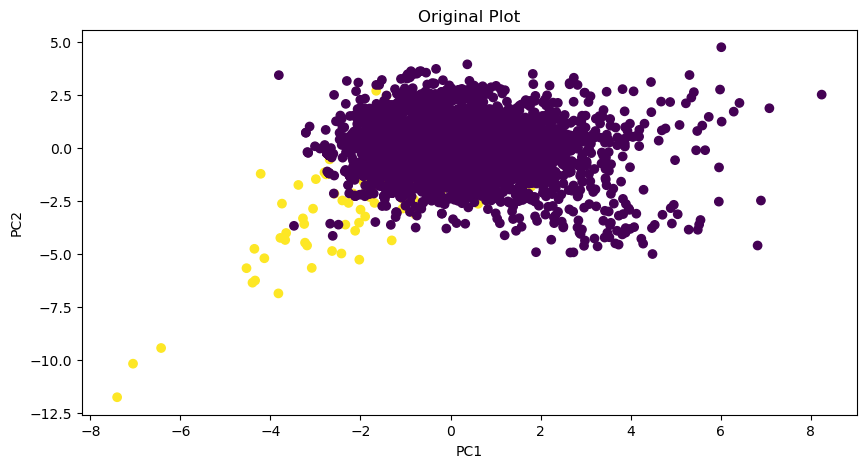

In [24]:
plt.figure(figsize=(10,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Original Plot")

In [29]:
lof = LocalOutlierFactor()
labels = lof.fit_predict(X_scaled)
labels

array([ 1, -1, -1, ...,  1,  1,  1], shape=(6916,))

Text(0.5, 1.0, 'Original Plot')

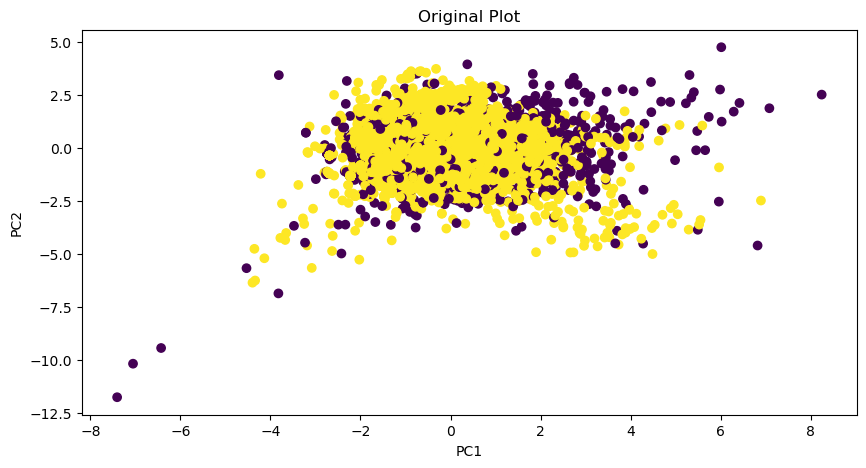

In [30]:
plt.figure(figsize=(10,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Original Plot")

In [31]:
lof = LocalOutlierFactor(contamination=0.036)
labels = lof.fit_predict(X_scaled)